<a href="https://colab.research.google.com/github/ChanchalSaha48/nlp-learning-journey/blob/main/03_machine_learning/02_Logistic%20Regression/TF_IDF%2BLogistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDb Sentiment Classification using TF-IDF and Logistic Regression

## Objective

In this projects, I build a binary sentiment classification model for IMDb movie reviews using:

- Text Preprocessing
- TF-IDF Vectorization
- Logistic Regression
- Model evaluation
- Confusion Matrix
- Feature weight analysis

The goal is to understand not only how to train the model, but also how TF-IDF features influence Logistic Regression.


## Import Libraries

In [1]:
!pip install opendatasets


In [2]:

import opendatasets as od

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
# Scikit-learn tools
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

#Evaluation metrics
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
od.download('https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

Skipping, found downloaded files in "./imdb-dataset-of-50k-movie-reviews" (use force=True to force download)


In [4]:
path='/content/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'


In [5]:
df=pd.read_csv(path)
print("Dataset shape: ",df.shape)
df.head()

Dataset shape:  (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Inspect the dataset

In [6]:
# check columns
print("Columns: ",df.columns)

Columns:  Index(['review', 'sentiment'], dtype='object')


In [7]:
# Convert Sentiment labels to Numerical labels

df['label']=df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [8]:
df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [9]:

df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


# Preprocessing

In [10]:
def preprocessing(text):
  text= BeautifulSoup(text,'html.parser').get_text()
  text=text.lower()
  return text


In [11]:
df['review']=df['review'].apply(preprocessing)

In [12]:
df.head()

,review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production. the filming tec...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there's a family where a little boy ...,negative,0
4,"petter mattei's ""love in the time of money"" is...",positive,1


## Split the dataset

In [13]:
x_train,x_test,y_train,y_test=train_test_split(df['review'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])

In [14]:
print("x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)

x_train shape:  (40000,)
y_train shape:  (40000,)
x_test shape:  (10000,)
y_test shape:  (10000,)


## TF-IDF Vectorization

In [15]:
tfidf=TfidfVectorizer(max_features=20000)

In [16]:
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

In [17]:
print("Training TF-IDF shape: ",x_train_tfidf.shape)
print("Testing TF-IDF Shape: ",x_test_tfidf.shape)

Training TF-IDF shape:  (40000, 20000)
Testing TF-IDF Shape:  (10000, 20000)


# Train Logistic Regression

In [18]:
model=LogisticRegression(max_iter=1000)

In [19]:
model.fit(x_train_tfidf,y_train)


LogisticRegression(max_iter=1000)

In [20]:
y_pred=model.predict(x_test_tfidf)

## Model Evaluation

In [21]:
acc=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print(f"Accuracy Score: {acc*100:.2f}%")
print(f"Precision Score: {precision*100:.2f}%")
print(f"Recall Score: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

Accuracy Score: 90.02%
Precision Score: 89.53%
Recall Score: 90.64%
F1-Score: 90.08%


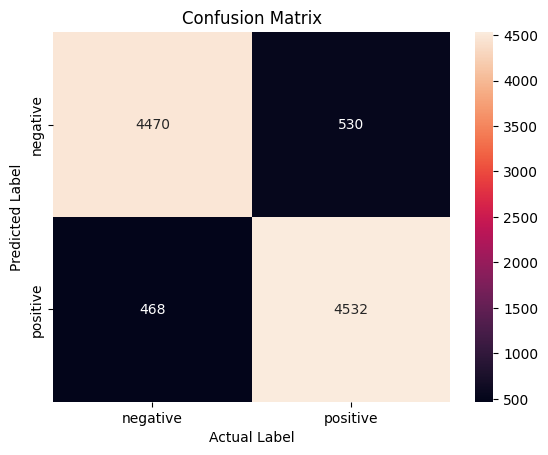

In [22]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['negative','positive'],yticklabels=['negative','positive'])
plt.title('Confusion Matrix')
plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.show()

In [23]:
cl=classification_report(y_test,y_pred,labels=['negative','positive'])
print(cl)

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         0
    positive       0.00      0.00      0.00         0

   micro avg       0.00      0.00      0.00         0
   macro avg       0.00      0.00      0.00         0
weighted avg       0.00      0.00      0.00         0



## Feature Names

In [24]:
feature_names=tfidf.get_feature_names_out()
print(feature_names.shape)
print("Number of features: ",len(feature_names))

print("\n Last 20 Features: ")
print(feature_names[-20:])

(20000,)
Number of features:  20000

 Last 20 Features: 
['zimmer' 'zip' 'ziyi' 'zizek' 'zodiac' 'zoe' 'zoey' 'zombi' 'zombie'
 'zombies' 'zone' 'zoo' 'zoom' 'zooming' 'zooms' 'zorro' 'zu' 'zucco'
 'zucker' 'zuniga']


## Model Weights

In [25]:
model.coef_.shape

(1, 20000)

In [26]:
weights=model.coef_[0]
print(weights.shape)
print("Number of weights: ",len(weights))
print("Lase 20 weights: ")
print(weights[-20:])

(20000,)
Number of weights:  20000
Lase 20 weights: 
[ 0.02884704 -0.16569466 -0.23182873  0.6252661   0.37659801 -0.02734286
 -1.1026953   0.33411707 -0.62433263 -1.64472623  0.01413345 -0.17392237
 -0.08947318  0.03707021  0.00291917  0.32236522  0.40148791 -0.77949228
  0.01248364 -0.18463564]


## Word + Weight DataFrame

In [28]:
feature_weights = pd.DataFrame({
    'word':feature_names,
    'weight': weights
})
feature_weights.head()

,word,weight
0,00,0.202635
1,000,-0.407873
2,007,0.122805
3,01,-0.013212
4,02,-0.113566


## Top positive Words

In [29]:
# Find words with the strongest positive weights

top_positive= feature_weights.sort_values(
    by='weight',
    ascending=False
)
print("Top positive words: ")
top_positive.head(20)

Top positive words: 


,word,weight
7877,great,8.233304
6342,excellent,7.229314
13084,perfect,5.575366
1890,best,5.311094
791,amazing,5.037116
19740,wonderful,4.981130
10695,loved,4.723159
6084,enjoyed,4.541006
8519,hilarious,4.362994
2415,brilliant,4.280468


## Top Negative Word

In [30]:
top_negative= feature_weights.sort_values(
    by='weight',
    ascending=True
)

In [31]:
print("Top Negative words: ")
top_negative.head(20)

Top Negative words: 


,word,weight
19792,worst,-10.945150
1503,bad,-8.804150
1445,awful,-8.208326
19398,waste,-8.005870
2231,boring,-7.143809
13502,poor,-6.358248
17854,terrible,-6.297146
12251,nothing,-5.576447
5654,dull,-5.402476
19789,worse,-5.282181


## Save Results

In [32]:
# Save feature weights for future analysis

feature_weights.to_csv(
    "feature_weights.csv",index=False
)
print("Feature weights saved succcessfully.")

Feature weights saved succcessfully.


## Conclusion

In this projects, I built a binary sentiment classification model using TF-IDF and Logistic Regression.

### Workflow

Text Data
- Train/Test split
- TF-IDF
- Logistic Regression
- Prediction
- Evaluation
- Confusion Matrix
- Feature Weight Analysis


The model learned positive and negative associations between text representation, machine learning, and model evaluation.
